# Homework 2: SPY on a 1-minute chart

The assignment has two parts: clean and analyze the data, then build a simple correlation trading rule. I’m using SPY and keeping the main test at 1 minute. There’s enough trading in SPY to try that without starting from 5-minute bars.

I want to see whether an indicator has any relationship with the return that comes **after** it. A smooth line on a chart by itself doesn’t answer that.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)
ROOT = Path.cwd()
REBUILD = False
BAR_MINUTES = 1
EMA_MINUTES = 20
RSI_MINUTES = 14
ATR_MINUTES = 14
CORR_MINUTES = 60
CORR_CUTOFF = 0.10
COST_BPS = 0.5

plt.rcParams.update({"figure.dpi": 130, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.18})

## a) Start with the trades

The downloads are huge, so I read one in chunks. Before making bars, I keep SPY trades with a valid time, positive price and size, and no correction/cancel flag. I also remove exact repeated records and prints that are late, out of sequence, or based on an average/reference price. Odd lots stay in: a small trade isn’t automatically a bad trade.

The session here is 9:30 to just before 16:00, New York time. The source timestamps are already Eastern time; they are not UTC. I check the file’s ordering rather than assuming the first row is always the earliest trade.

The chunk-reading code is in `spy_data.py` so the notebook doesn’t turn into a wall of file-handling code. The filter and trading calculations are below.

### Why 1 minute?

Five minutes is a choice, not a requirement. A full session gives 390 one-minute bars versus 78 five-minute bars. I’d rather start at 1 minute and check what happens when I aggregate it later.

The trade-off is noise: a 1-minute move is small, and the spread can eat a lot of it. More bars also doesn’t mean more independent evidence. We still only have a few trading days.

Each bar is labeled by its **start**. The 9:30 bar covers 9:30:00–9:30:59.999…; its close is only known at 9:31. OHLC uses the actual trade order, volume is summed, and VWAP is total price × size divided by total size.

In [2]:
from spy_data import load_bars

bars, audit = load_bars(ROOT, rebuild=REBUILD)
print(f"{audit['raw_rows']:,} trade records → {audit['kept_rows']:,} kept")
print(f"{len(bars):,} minute bars across {audit['sessions']} sessions")
print(f"{bars.index[0].date()} to {bars.index[-1].date()}")
print("Identical downloads:", audit["duplicate_download"])
print("Times are New York time; no missing minute is filled in.")
display(bars.head().round(4))

audit_table = pd.DataFrame({"records removed": audit["removed"]})
audit_table.loc["kept", "records removed"] = audit["kept_rows"]
display(audit_table.astype(int))

10,757,236 trade records → 8,956,677 kept
5,850 minute bars across 15 sessions
2026-09-14 to 2026-10-02
Identical downloads: True
Times are New York time; no missing minute is filled in.


,open,high,low,close,volume,trades,vwap
bar_time,,,,,,,
2026-09-14 09:30:00-04:00,759.00,759.220,758.640,758.7500,678766.2575,6167,759.0545
2026-09-14 09:31:00-04:00,758.71,759.050,758.580,758.8250,335838.0429,3167,758.8315
2026-09-14 09:32:00-04:00,758.83,759.115,758.740,758.9880,210490.7037,2495,758.9535
2026-09-14 09:33:00-04:00,758.98,759.040,758.757,758.7799,86127.3297,1889,758.8884
2026-09-14 09:34:00-04:00,758.78,759.140,758.670,758.6850,111509.8833,1755,758.7949


,records removed
other_symbol,0
invalid_timestamp,0
duplicate_record,0
invalid_price_or_size,45
correction_or_cancel,108
stopped_trade,0
sale_condition,1799861
outside_session,545
kept,8956677


### What’s actually in the sample?

I check the dates instead of calling this “two weeks” from memory. A full-day bar count is useful here: if a minute is missing, I want to see it rather than invent a price for it.

I keep the final five sessions aside for the later test. The earlier sessions are where I inspect the indicators. The window lengths and the 0.10 correlation cutoff above are simple starting choices, not values picked to maximize the final test return.

In [3]:
sessions = bars.index.normalize().unique().sort_values()
if len(sessions) < 8:
    raise ValueError("Need at least 8 sessions for this split.")
train_days, test_days = sessions[:-5], sessions[-5:]
train_mask = bars.index.normalize().isin(train_days)
test_mask = bars.index.normalize().isin(test_days)

session_summary = bars.groupby(bars.index.normalize()).agg(
    minutes=("close", "size"), trades=("trades", "sum"),
    shares=("volume", "sum"), first_open=("open", "first"), last_close=("close", "last"))
session_summary["open to close (%)"] = 100 * (session_summary["last_close"] / session_summary["first_open"] - 1)
session_summary.index = session_summary.index.strftime("%b %d")
print(f"Earlier sample: {len(train_days)} sessions, {train_days[0].date()}–{train_days[-1].date()}")
print(f"Later test: {len(test_days)} sessions, {test_days[0].date()}–{test_days[-1].date()}")
display(session_summary.round(3))

within_day = bars.groupby(bars.index.normalize())["close"].pct_change(fill_method=None)
training_returns = within_day.loc[train_mask].dropna() * 10_000
print(f"Earlier-sample mean: {training_returns.mean():.3f} bps per minute")
print(f"Earlier-sample std:  {training_returns.std():.3f} bps per minute")
print(f"Lag-1 correlation:  {training_returns.corr(within_day.groupby(bars.index.normalize()).shift(1).loc[train_mask] * 10_000):.3f}")

Earlier sample: 10 sessions, 2026-09-14–2026-09-25
Later test: 5 sessions, 2026-09-28–2026-10-02


,minutes,trades,shares,first_open,last_close,open to close (%)
bar_time,,,,,,
Sep 14,390,528030,2.977365e+07,759.000,760.780,0.235
Sep 15,390,457491,2.499913e+07,760.117,757.360,-0.363
Sep 16,390,667529,4.110635e+07,759.500,754.095,-0.712
Sep 17,390,510412,3.001867e+07,763.140,762.660,-0.063
Sep 18,390,482535,2.961018e+07,761.310,761.640,0.043
Sep 21,390,569564,3.496195e+07,766.270,773.520,0.946
Sep 22,390,425243,2.209527e+07,773.980,773.360,-0.080
Sep 23,390,577462,3.216321e+07,772.790,767.750,-0.652
Sep 24,390,562622,2.962045e+07,764.065,767.250,0.417


Earlier-sample mean: 0.006 bps per minute
Earlier-sample std:  2.334 bps per minute
Lag-1 correlation:  0.093


### How noisy are the minute returns?

These two plots use the earlier sample. Returns are in basis points: 1 bp is 0.01%. The histogram zooms to the middle 99% so a few tails don’t squash everything else; those tails stay in the calculations.

The second plot separates the clock-time pattern from the overnight gaps. The counts in the cleaning table are sequential: each record is counted under the first rule that removes it.

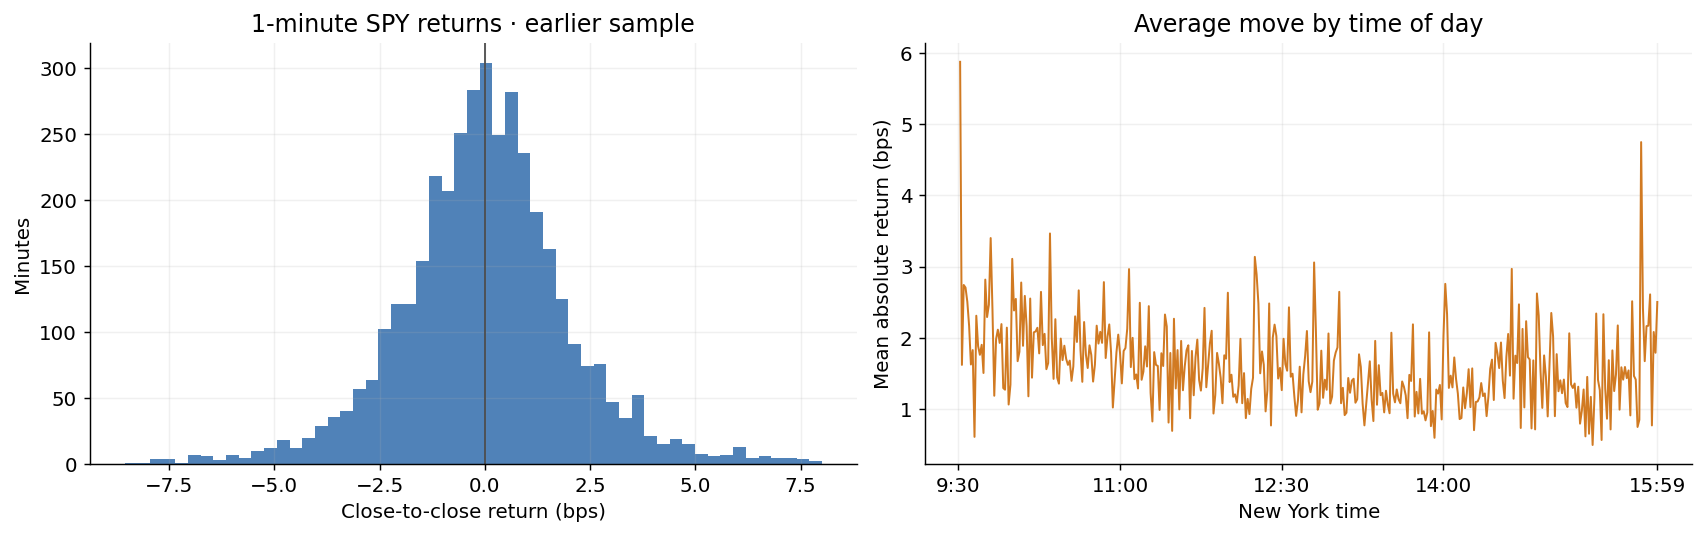

In [4]:
BLUE, ORANGE, GREEN, RED = "#2463a6", "#d17a22", "#238b68", "#bb4b52"

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
lo, hi = training_returns.quantile([0.005, 0.995])
axes[0].hist(training_returns, bins=55, range=(lo, hi), color=BLUE, alpha=0.8)
axes[0].axvline(0, color="0.3", lw=1)
axes[0].set(title="1-minute SPY returns · earlier sample", xlabel="Close-to-close return (bps)", ylabel="Minutes")

profile = bars.loc[train_mask].copy()
profile["clock_minute"] = profile.index.hour * 60 + profile.index.minute
profile["abs_return"] = within_day.loc[train_mask].abs() * 10_000
profile = profile.groupby("clock_minute")["abs_return"].mean()
axes[1].plot(profile.index, profile.values, color=ORANGE, lw=1.1)
axes[1].set(xticks=[570, 660, 750, 840, 959], xticklabels=["9:30", "11:00", "12:30", "14:00", "15:59"],
            title="Average move by time of day", xlabel="New York time", ylabel="Mean absolute return (bps)")
plt.show()

### Kalman filter: smooth the signal, keep the prices

I’m using a simple local-level Kalman filter on log price. It takes the previous estimate, adds uncertainty, then adjusts toward the newest close. In the update below, $K$ is the weight on the new observation.

$$P^-_t=P_{t-1}+Q,\qquad K_t=\frac{P^-_t}{P^-_t+R}$$
$$m_t=m_{t-1}+K_t(z_t-m_{t-1}),\qquad P_t=(1-K_t)P^-_t$$

Here $z_t$ is log price, $Q=10^{-8}$, and $R=4\times10^{-8}$. Those are fixed log-price variances, not estimates of the true noise. Their ratio makes the filter less jumpy than the close. I reset it at the start of each day so an overnight move doesn’t get treated as a minute of trading.

I chose Kalman over the usual centered Savitzky–Golay filter because a centered fit uses neighboring points on both sides. A trailing Savitzky–Golay fit would also be possible. Kalman is easier to keep causal here.

This step is smoothing, not deleting “bad” market moves. I don’t interpolate spikes away. The backtest will still use observed trade prices.

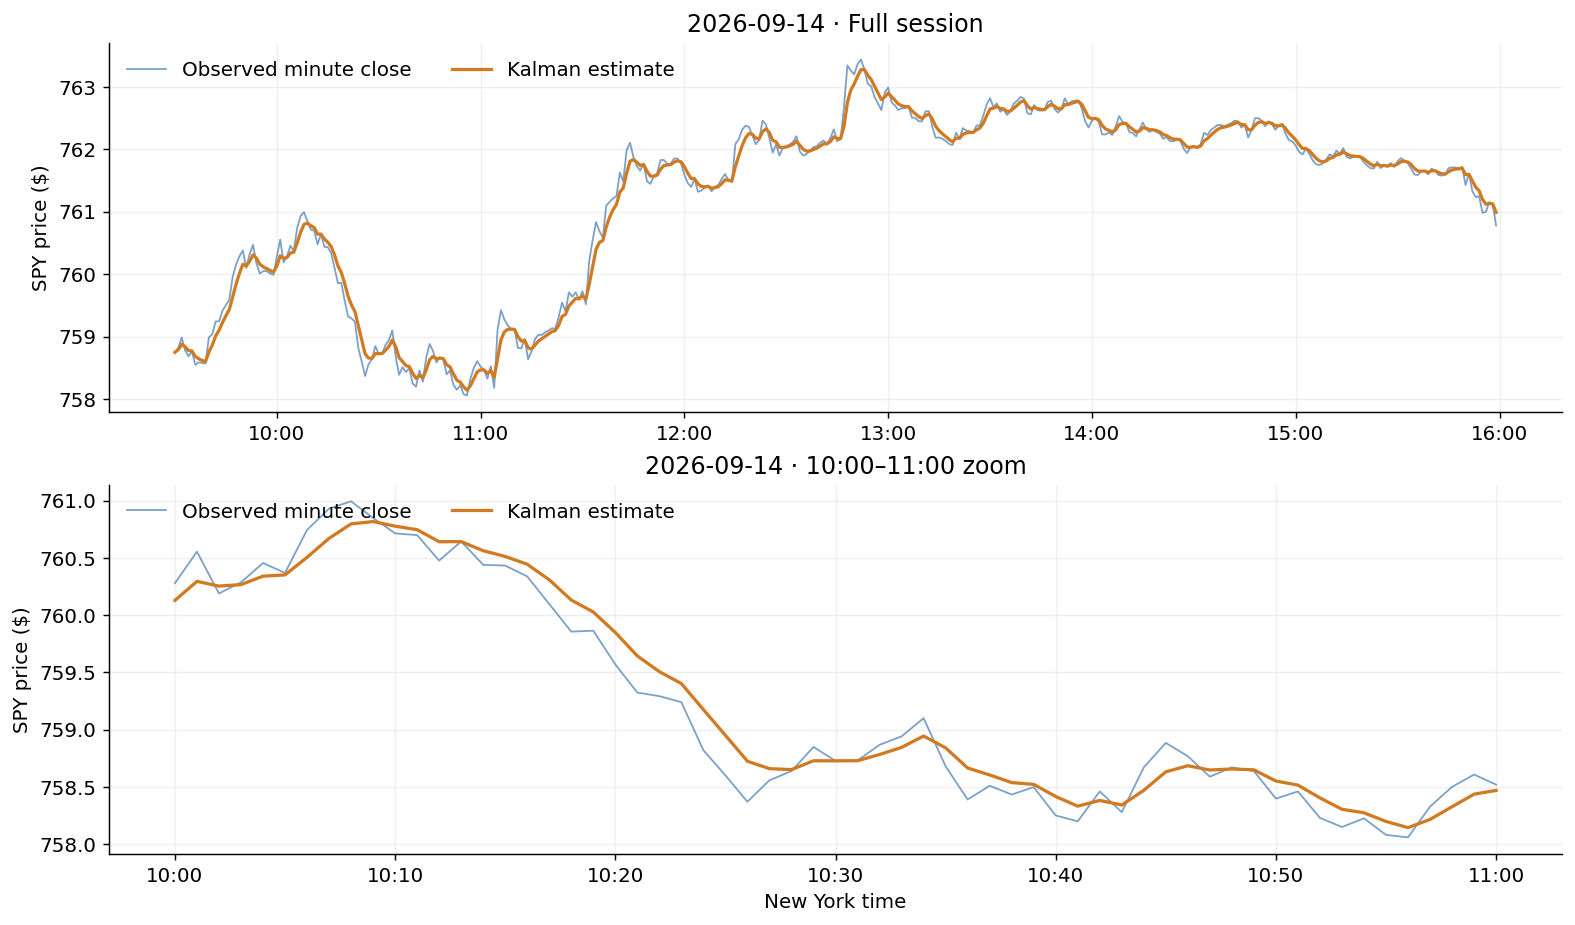

In [5]:
def kalman_price(price, process_var=1e-8, measurement_var=4e-8):
    z = np.log(np.asarray(price, dtype=float))
    estimate = np.empty(len(z))
    estimate[0], variance = z[0], measurement_var
    for i in range(1, len(z)):
        predicted_var = variance + process_var
        weight = predicted_var / (predicted_var + measurement_var)
        estimate[i] = estimate[i - 1] + weight * (z[i] - estimate[i - 1])
        variance = (1 - weight) * predicted_var
    return pd.Series(np.exp(estimate), index=price.index)

bars["kalman"] = bars.groupby(bars.index.normalize())["close"].transform(kalman_price)
example_day = train_days[0]  # Keep the example fixed before looking at the test.
example = bars.loc[bars.index.normalize() == example_day]
zoom = example.between_time("10:00", "11:00")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
for ax, sample, title in [(axes[0], example, "Full session"), (axes[1], zoom, "10:00–11:00 zoom")]:
    ax.plot(sample.index, sample["close"], color=BLUE, lw=1, alpha=0.6, label="Observed minute close")
    ax.plot(sample.index, sample["kalman"], color=ORANGE, lw=1.8, label="Kalman estimate")
    ax.set(title=f"{example_day.date()} · {title}", ylabel="SPY price ($)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=sample.index.tz))
    ax.legend(loc="upper left", frameon=False, ncol=2)
axes[1].set_xlabel("New York time")
plt.show()

## b) Turn the indicators into something we can correlate

My main input is the distance from the Kalman price to its EMA, divided by ATR. Above the EMA gives a positive value; below gives a negative one. Dividing by ATR makes a $0.20 gap mean less during a volatile stretch.

I also calculate centered RSI and the last price change divided by ATR. RSI is centered at 50. ATR alone has no long/short direction, so the ATR version needs a signed price change.

EMA uses 20 minutes. RSI and ATR use 14 minutes with Wilder’s recursive average, seeded with the first simple average. Flat prices give RSI 50; gains with no losses give 100. All three reset by session and stay unavailable during their warm-up.

In [6]:
def wilder_mean(values, length):
    result = pd.Series(np.nan, index=values.index, dtype=float)
    valid = values.dropna()
    if len(valid) < length:
        return result
    average = valid.iloc[:length].mean()
    result.loc[valid.index[length - 1]] = average
    for time, value in valid.iloc[length:].items():
        average += (value - average) / length
        result.loc[time] = average
    return result


def make_features(price_bars, minutes=1):
    pieces = []
    ema_n = max(2, int(np.ceil(EMA_MINUTES / minutes)))
    rsi_n = max(2, int(np.ceil(RSI_MINUTES / minutes)))
    atr_n = max(2, int(np.ceil(ATR_MINUTES / minutes)))
    for _, day in price_bars.groupby(price_bars.index.normalize()):
        day = day.copy()
        day["kalman"] = kalman_price(day["close"], process_var=1e-8 * minutes)
        day["ema"] = day["kalman"].ewm(span=ema_n, adjust=False, min_periods=ema_n).mean()
        change = day["kalman"].diff()
        up = wilder_mean(change.clip(lower=0), rsi_n)
        down = wilder_mean(-change.clip(upper=0), rsi_n)
        day["rsi"] = 100 - 100 / (1 + up / down.replace(0, np.nan))
        day.loc[down.eq(0) & up.gt(0), "rsi"] = 100
        day.loc[down.eq(0) & up.eq(0), "rsi"] = 50

        previous_close = day["close"].shift(1)
        true_range = pd.concat([day["high"] - day["low"],
                                (day["high"] - previous_close).abs(),
                                (day["low"] - previous_close).abs()], axis=1).max(axis=1)
        day["atr"] = wilder_mean(true_range, atr_n)
        scale = day["atr"].replace(0, np.nan)
        day["ema_gap"] = (day["kalman"] - day["ema"]) / scale
        day["rsi_centered"] = (day["rsi"] - 50) / 50
        day["atr_move"] = change / scale
        pieces.append(day)
    return pd.concat(pieces)

features = make_features(bars)
FEATURES = {"ema_gap": "EMA distance / ATR", "rsi_centered": "Centered RSI", "atr_move": "Price change / ATR"}
display(features.loc[train_mask, ["ema", "rsi", "atr", *FEATURES]].describe().round(3))

,ema,rsi,atr,ema_gap,rsi_centered,atr_move
count,3710.000,3760.000,3770.000,3710.000,3760.000,3770.000
mean,764.942,51.700,0.321,0.062,0.034,0.006
std,5.688,20.356,0.171,0.919,0.407,0.259
min,751.325,0.698,0.113,-3.064,-0.986,-1.239
25%,759.835,35.836,0.212,-0.548,-0.283,-0.155
50%,763.416,53.084,0.277,0.088,0.062,0.002
75%,769.767,66.770,0.369,0.667,0.335,0.162
max,774.600,95.298,1.287,3.237,0.906,1.808


### Correlation with a later return

Correlating price with its EMA would mostly tell me that two price lines move together. I’m interested in the tradable move **after** the indicator instead.

At the end of bar $t$, the feature is $x_t$. The earliest fill I allow is the open of bar $t+1$. I hold until the open of $t+2$, so the target is

$$y_t=\frac{O_{t+2}}{O_{t+1}}-1.$$

By the end of bar $t$, $y_{t-2}$ is known, but $y_t$ isn’t. The rolling Pearson correlation therefore pairs `x.shift(2)` with the open-to-open return that has just finished. It uses the last 60 complete pairs within the same session. Missing warm-up values don’t count.

Positive correlation means the feature and the later return recently lined up. Negative correlation means they tended to oppose each other. A correlation near zero gives me no reason to trade. The sign can change; 0.10 is a trading cutoff, not a claim of statistical significance.

In [7]:
def add_correlations(feature_frame, minutes=1):
    window = max(3, int(np.ceil(CORR_MINUTES / minutes)))
    pieces = []
    for _, day in feature_frame.groupby(feature_frame.index.normalize()):
        day = day.copy()
        known_return = day["open"].pct_change(fill_method=None)
        for name in FEATURES:
            day[f"corr_{name}"] = day[name].shift(2).rolling(window, min_periods=window).corr(known_return)
        # This forward value is only for the later diagnostic scatterplot.
        day["future_return"] = day["open"].shift(-2) / day["open"].shift(-1) - 1
        pieces.append(day)
    return pd.concat(pieces)

features = add_correlations(features)
earlier_correlations = []
for name, label in FEATURES.items():
    earlier = features.loc[train_mask, [name, "future_return"]].dropna()
    earlier_correlations.append({"input": label, "pairs": len(earlier),
                                 "correlation with later return": earlier[name].corr(earlier["future_return"])})
display(pd.DataFrame(earlier_correlations).set_index("input").round(4))

,pairs,correlation with later return
input,,
EMA distance / ATR,3690,-0.0044
Centered RSI,3740,-0.0041
Price change / ATR,3750,0.0608


### Does the relationship show up on a plot?

The dots below are the earlier-sample observations. The orange points are average returns in ten equal-count feature bins. I’m keeping the scatter faint so the averages are readable. A messy, mostly flat cloud is useful information too; it doesn’t need a story forced onto it.

The following chart uses the same fixed example day. Price, RSI, ATR, and correlation get separate axes because their units are different.

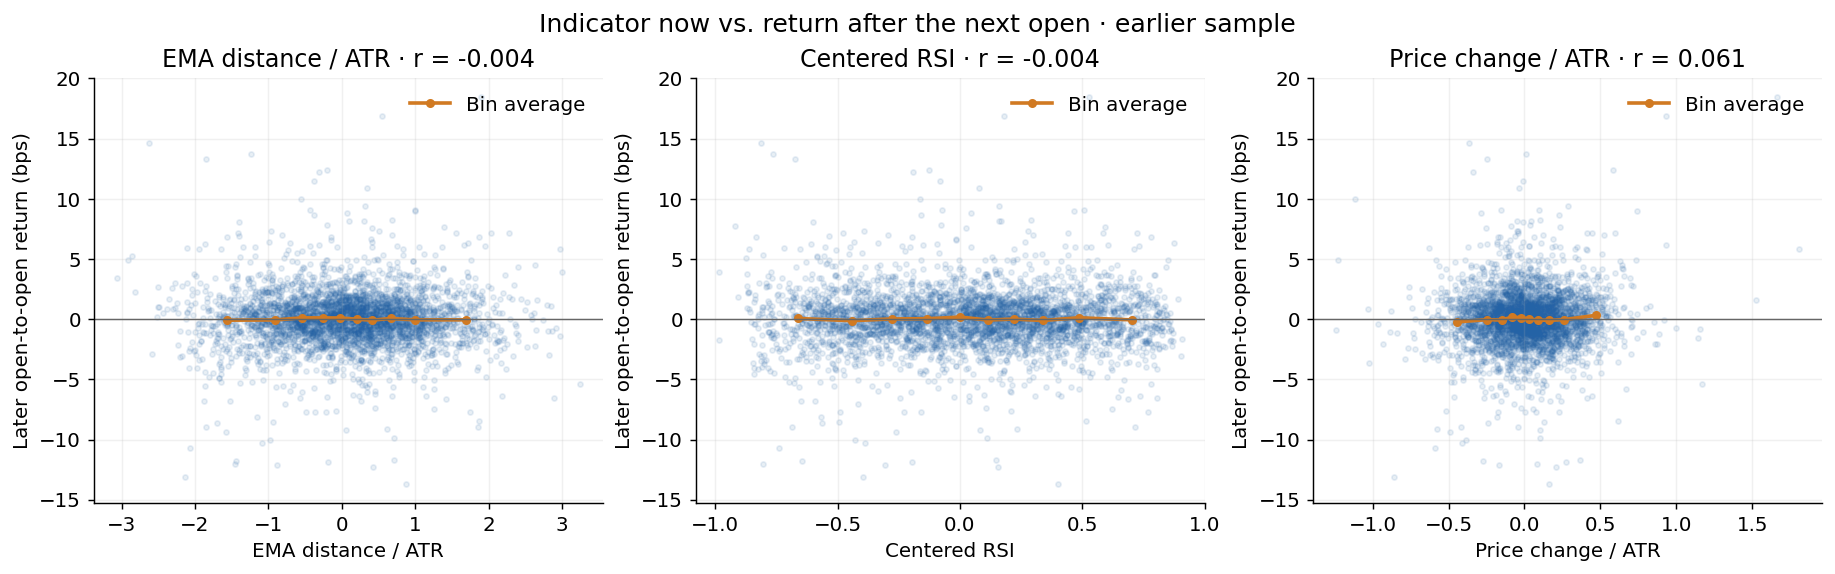

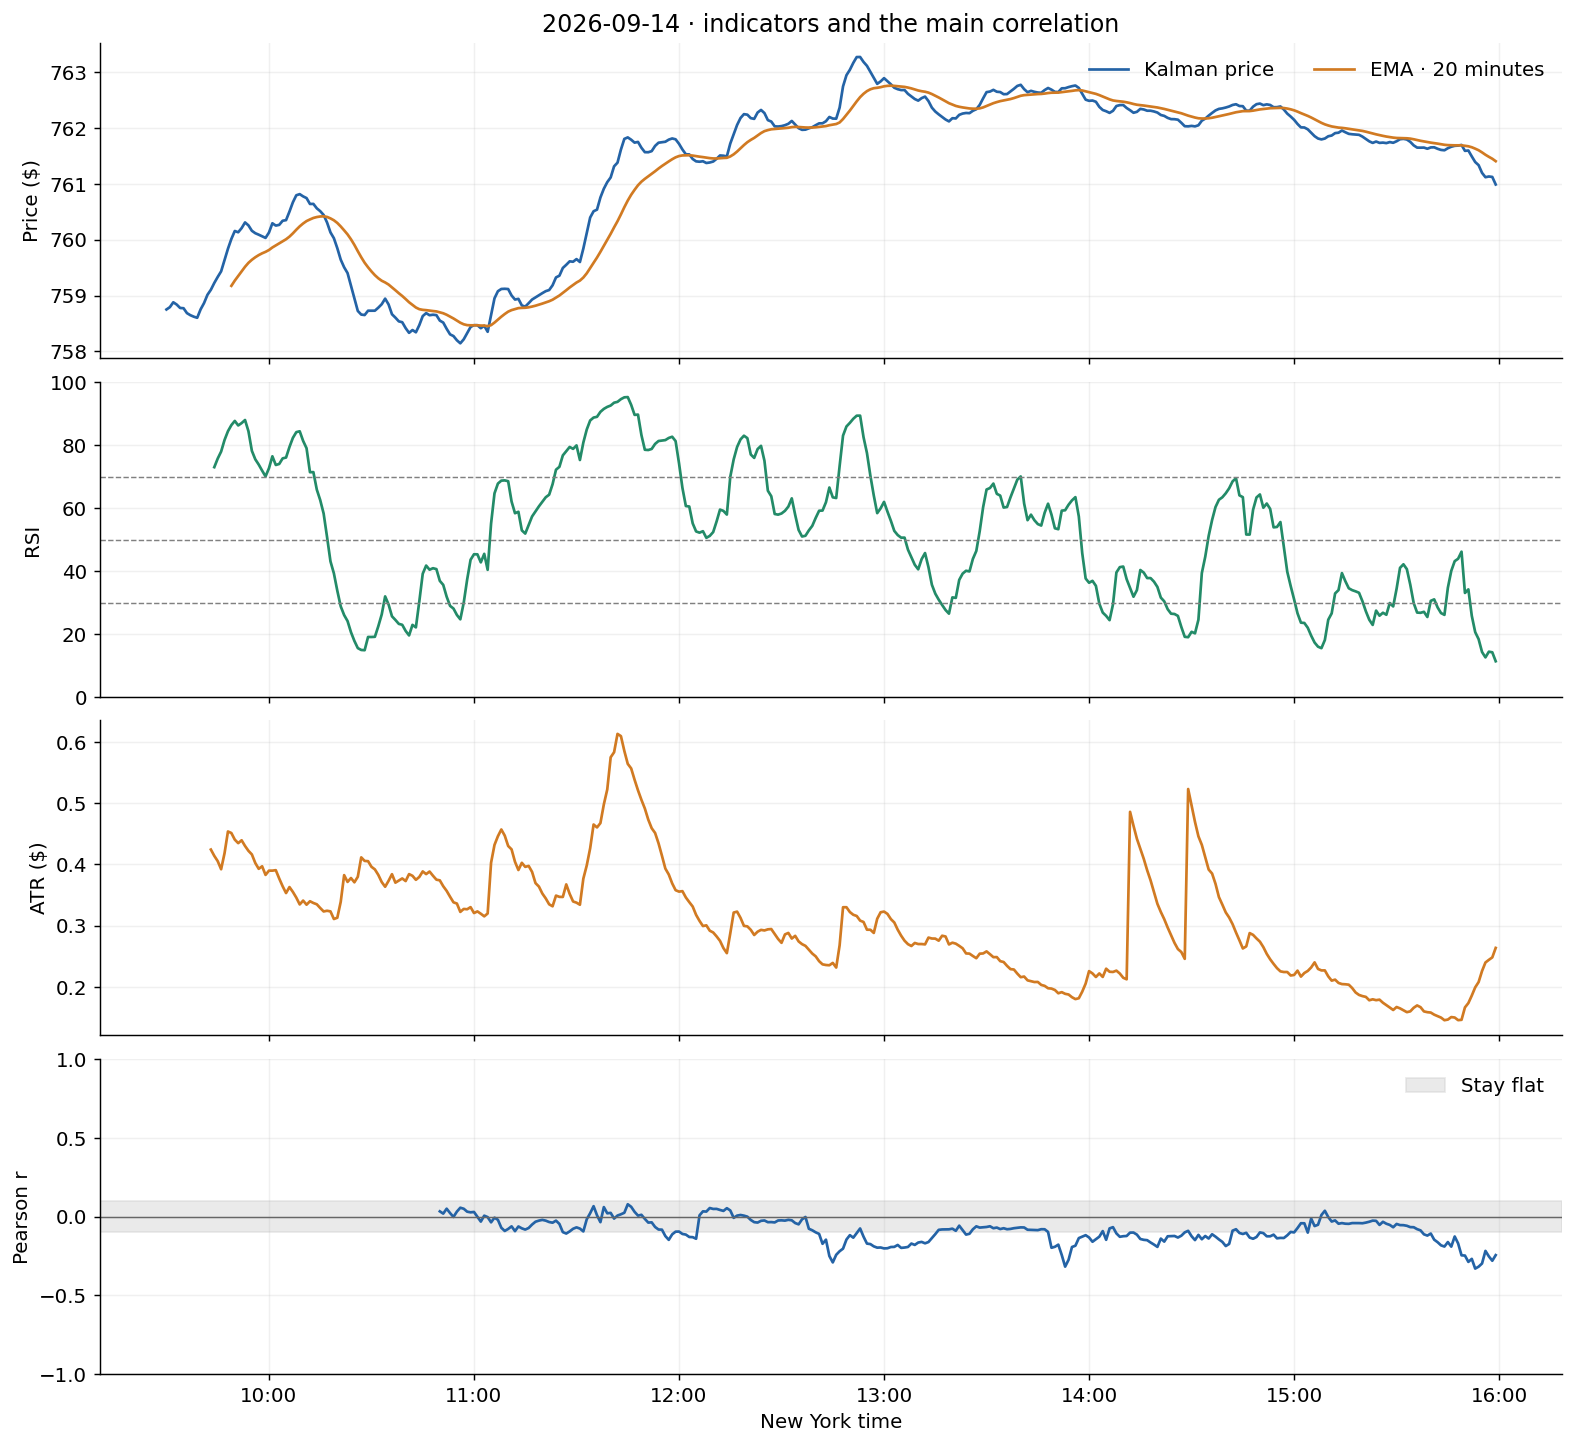

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), constrained_layout=True)
for ax, (name, label) in zip(axes, FEATURES.items()):
    sample = features.loc[train_mask, [name, "future_return"]].dropna().copy()
    sample["return_bps"] = sample["future_return"] * 10_000
    ax.scatter(sample[name], sample["return_bps"], s=8, alpha=0.10, color=BLUE, rasterized=True)
    sample["bin"] = pd.qcut(sample[name], 10, duplicates="drop")
    averages = sample.groupby("bin", observed=True)[[name, "return_bps"]].mean()
    ax.plot(averages[name], averages["return_bps"], "o-", color=ORANGE, lw=2, ms=4, label="Bin average")
    ax.axhline(0, color="0.4", lw=0.8)
    rho = sample[name].corr(sample["future_return"])
    ax.set(title=f"{label} · r = {rho:.3f}", xlabel=label, ylabel="Later open-to-open return (bps)")
    ax.legend(frameon=False, loc="upper right")
fig.suptitle("Indicator now vs. return after the next open · earlier sample", fontsize=14)
plt.show()

example_features = features.loc[features.index.normalize() == example_day]
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True, constrained_layout=True)
axes[0].plot(example_features.index, example_features["kalman"], color=BLUE, label="Kalman price")
axes[0].plot(example_features.index, example_features["ema"], color=ORANGE, label="EMA · 20 minutes")
axes[0].set(ylabel="Price ($)", title=f"{example_day.date()} · indicators and the main correlation")
axes[0].legend(frameon=False, ncol=2)
axes[1].plot(example_features.index, example_features["rsi"], color=GREEN)
for level in [30, 50, 70]:
    axes[1].axhline(level, color="0.5", ls="--", lw=0.8)
axes[1].set(ylabel="RSI", ylim=(0, 100))
axes[2].plot(example_features.index, example_features["atr"], color=ORANGE)
axes[2].set(ylabel="ATR ($)")
axes[3].plot(example_features.index, example_features["corr_ema_gap"], color=BLUE)
axes[3].axhspan(-CORR_CUTOFF, CORR_CUTOFF, color="0.8", alpha=0.4, label="Stay flat")
axes[3].axhline(0, color="0.4", lw=0.8)
axes[3].set(ylabel="Pearson r", ylim=(-1, 1), xlabel="New York time")
axes[3].legend(frameon=False)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=example_features.index.tz))
plt.show()

### The trading rule

EMA distance is the main version. I calculate the 60-minute correlation at each completed bar. If its absolute value is below 0.10, I stay flat. Otherwise:

| Current EMA gap | Positive correlation | Negative correlation |
| --- | --- | --- |
| Above the EMA | Long | Short |
| Below the EMA | Short | Long |

In code, that’s the sign of `feature × correlation`. The RSI and ATR-scaled versions use exactly the same rule. I don’t switch to whichever one makes the later sample look best.

A signal at the end of the 10:00 bar can first trade at the 10:01 open. It earns the return from that open to the 10:02 open. The last open of each day is a scheduled exit, so no position carries overnight. For the 1-minute test that exit is 15:59; the final minute is left out.

I assume fills at the next observed opening trade and charge 0.5 bp per unit of turnover. Entering and exiting each cost once; a direct long-to-short flip costs twice. This is an idealized fill assumption: the trade file doesn’t tell me the bid/ask spread, queue position, or short borrow cost.

In [9]:
def backtest(feature_frame, feature="ema_gap", cost_bps=COST_BPS, cutoff=CORR_CUTOFF):
    if feature not in FEATURES:
        raise ValueError(f"Choose one of {list(FEATURES)}")
    pieces = []
    for _, day in feature_frame.groupby(feature_frame.index.normalize()):
        day = day.copy()
        rho = day[f"corr_{feature}"]
        day["signal"] = np.sign(day[feature] * rho).where(rho.abs().ge(cutoff), 0).fillna(0)
        day["position"] = day["signal"].shift(1).fillna(0)
        # Exit at the last open, rather than getting an overnight return for free.
        day.iloc[-1, day.columns.get_loc("position")] = 0
        day["holding_return"] = (day["open"].shift(-1) / day["open"] - 1).fillna(0)
        previous = day["position"].shift(1).fillna(0)
        day["turnover"] = (day["position"] - previous).abs()
        day["gross_return"] = day["position"] * day["holding_return"]
        day["cost"] = day["turnover"] * cost_bps / 10_000
        day["net_return"] = day["gross_return"] - day["cost"]
        day["entry"] = day["position"].ne(0) & day["position"].ne(previous)
        # Same opening prices and exit time for a simple intraday SPY benchmark.
        benchmark_position = pd.Series(1.0, index=day.index)
        benchmark_position.iloc[-1] = 0
        benchmark_turnover = benchmark_position.diff().abs().fillna(1)
        day["benchmark_return"] = benchmark_position * day["holding_return"] - benchmark_turnover * cost_bps / 10_000
        pieces.append(day)
    return pd.concat(pieces)

main_result = backtest(features)
example_result = main_result.loc[main_result.index.normalize() == example_day]
display(example_result.loc[example_result["position"].ne(example_result["position"].shift(1)) & example_result["corr_ema_gap"].notna(),
                           ["ema_gap", "corr_ema_gap", "signal", "position", "turnover"]].head(10).round(4))

,ema_gap,corr_ema_gap,signal,position,turnover
bar_time,,,,,
2026-09-14 11:28:00-04:00,1.3307,-0.0937,0.0,-1.0,1.0
2026-09-14 11:29:00-04:00,1.2292,-0.0770,0.0,0.0,1.0
2026-09-14 11:57:00-04:00,1.0189,-0.1473,-1.0,-1.0,1.0
2026-09-14 12:00:00-04:00,0.6175,-0.0945,0.0,0.0,1.0
2026-09-14 12:02:00-04:00,0.0540,-0.1138,-1.0,-1.0,1.0
2026-09-14 12:05:00-04:00,-0.2949,-0.1402,1.0,1.0,2.0
2026-09-14 12:07:00-04:00,-0.2497,0.0336,0.0,0.0,1.0
2026-09-14 12:42:00-04:00,0.2491,-0.1724,-1.0,-1.0,1.0
2026-09-14 12:54:00-04:00,1.8662,-0.1270,-1.0,0.0,1.0


### What did it earn after costs?

I show the earlier sample and the later five-session test separately. The EMA rule stays the main result; the other inputs are comparisons. I’m reporting return, drawdown, and trading activity rather than annualizing a Sharpe ratio from a few days.

The benchmark holds SPY during the same intraday opening-price intervals and is flat overnight. It also pays entry/exit costs. It isn’t an overnight buy-and-hold portfolio.

gross (%)  net (%)  SPY intraday (%)  max drawdown (%)  entries incl. flips  \
input              sample                                                                                    
EMA distance / ATR Earlier        -0.072   -2.851             0.077            -3.386                  282   
                   Later test      0.594   -0.834            -1.311            -1.625                  143   
Centered RSI       Earlier         0.165   -2.659             0.077            -3.201                  286   
                   Later test      0.610   -0.788            -1.311            -1.362                  140   
Price change / ATR Earlier        -0.509   -5.125             0.077            -5.205                  475   
                   Later test      0.302   -2.047            -1.311            -2.314                  237   

                               minutes invested (%)  turnover  
input              sample                                      
EMA distance / ATR Earlier                   50.179       564  
                   Later test                56.103       286  
Centered RSI       Earlier                   53.436       572  
                   Later test                58.667       280  
Price change / ATR Earlier                   31.897       950  
                   Later test                31.641       474

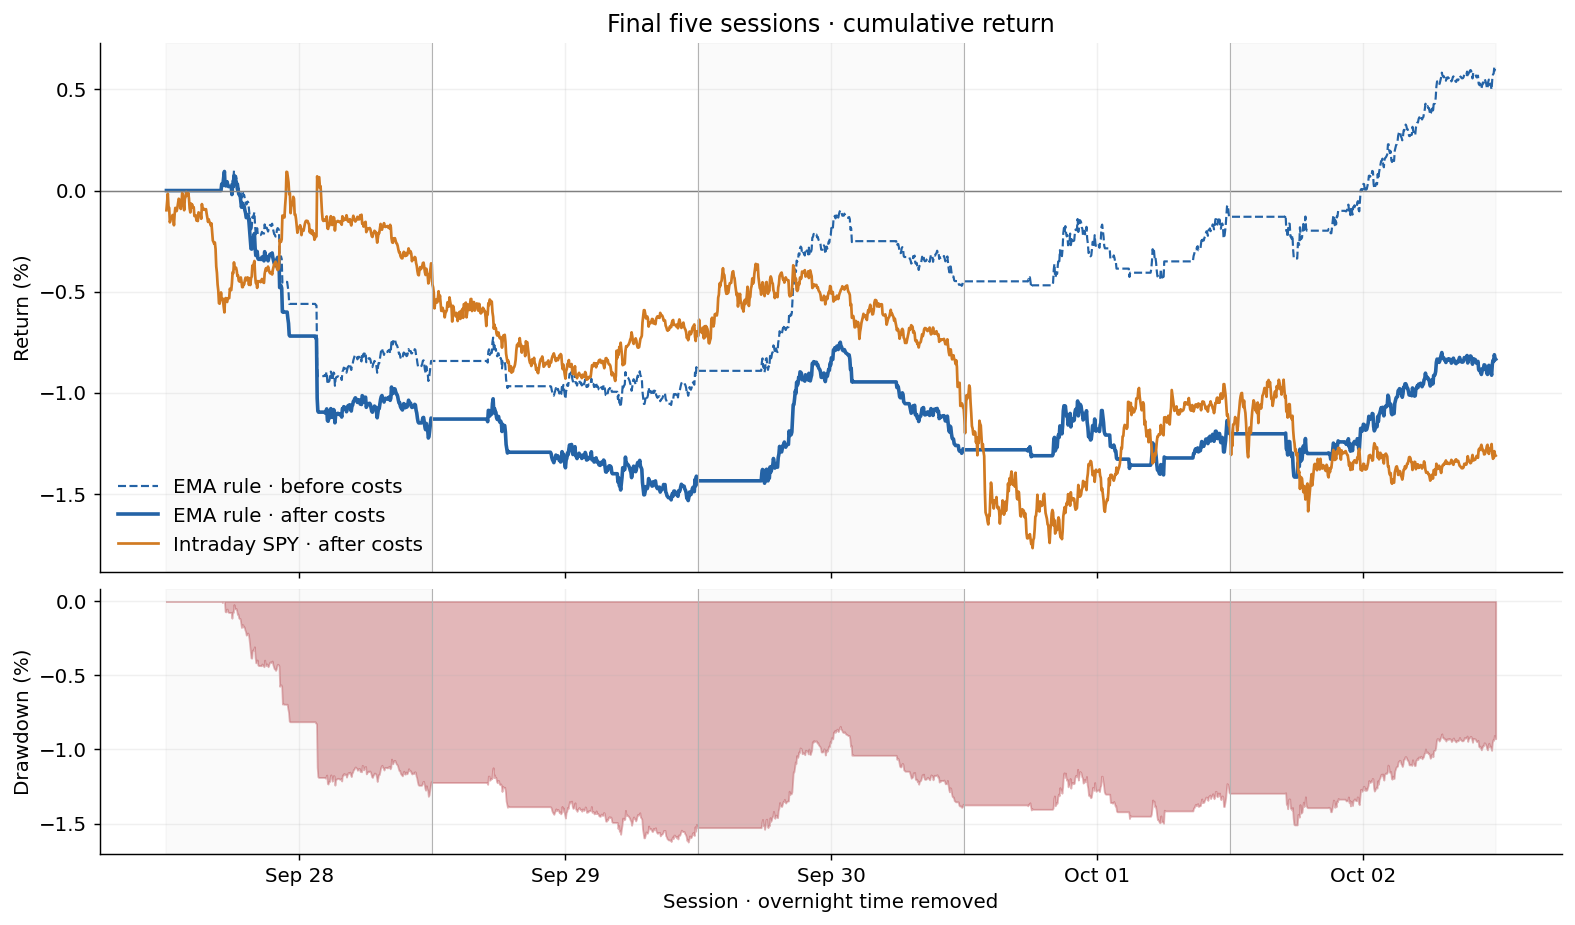

,gross,net,cost_bps,entries
bar_time,,,,
Sep 28,-0.843,-1.130,29.0,29
Sep 29,-0.049,-0.309,26.0,26
Sep 30,0.446,0.156,29.0,29
Oct 01,0.321,0.080,24.0,24
Oct 02,0.725,0.373,35.0,35


In [10]:
def performance(result):
    net_equity = np.r_[1.0, (1 + result["net_return"]).cumprod().to_numpy()]
    peak = np.maximum.accumulate(net_equity)
    return {"gross (%)": 100 * ((1 + result["gross_return"]).prod() - 1),
            "net (%)": 100 * (net_equity[-1] - 1),
            "SPY intraday (%)": 100 * ((1 + result["benchmark_return"]).prod() - 1),
            "max drawdown (%)": 100 * (net_equity / peak - 1).min(),
            "entries incl. flips": int(result["entry"].sum()),
            "minutes invested (%)": 100 * result["position"].ne(0).mean(),
            "turnover": int(result["turnover"].sum())}

variants = {name: backtest(features, feature=name) for name in FEATURES}
rows = []
for name, result in variants.items():
    for sample_name, mask in [("Earlier", train_mask), ("Later test", test_mask)]:
        rows.append({"input": FEATURES[name], "sample": sample_name, **performance(result.loc[mask])})
results_table = pd.DataFrame(rows).set_index(["input", "sample"])
display(results_table.round(3))

test_result = main_result.loc[test_mask].copy()
test_equity = (1 + test_result["net_return"]).cumprod()
gross_equity = (1 + test_result["gross_return"]).cumprod()
benchmark_equity = (1 + test_result["benchmark_return"]).cumprod()
seeded_peak = np.maximum.accumulate(np.r_[1, test_equity.to_numpy()])[1:]
drawdown = test_equity.to_numpy() / seeded_peak - 1
x = np.arange(len(test_result))
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(x, (gross_equity - 1) * 100, color=BLUE, ls="--", lw=1.2, label="EMA rule · before costs")
axes[0].plot(x, (test_equity - 1) * 100, color=BLUE, lw=2, label="EMA rule · after costs")
axes[0].plot(x, (benchmark_equity - 1) * 100, color=ORANGE, lw=1.5, label="Intraday SPY · after costs")
axes[0].axhline(0, color="0.5", lw=0.8)
axes[0].set(title="Final five sessions · cumulative return", ylabel="Return (%)")
axes[0].legend(frameon=False, loc="lower left")
axes[1].fill_between(x, drawdown * 100, 0, color=RED, alpha=0.4)
axes[1].set(ylabel="Drawdown (%)", xlabel="Session · overnight time removed")
centers, labels = [], []
for i, day in enumerate(test_days):
    ids = np.flatnonzero(test_result.index.normalize() == day)
    centers.append((ids[0] + ids[-1]) / 2)
    labels.append(day.strftime("%b %d"))
    for ax in axes:
        if i % 2 == 0:
            ax.axvspan(ids[0], ids[-1], color="0.5", alpha=0.04)
        if i:
            ax.axvline(ids[0], color="0.7", lw=0.6)
axes[1].set_xticks(centers, labels)
plt.show()

daily_test = test_result.groupby(test_result.index.normalize()).agg(
    gross=("gross_return", lambda r: 100 * ((1 + r).prod() - 1)),
    net=("net_return", lambda r: 100 * ((1 + r).prod() - 1)),
    cost_bps=("cost", lambda r: r.sum() * 10_000), entries=("entry", "sum"))
daily_test.index = daily_test.index.strftime("%b %d")
display(daily_test.round(3))

### How much do trading costs matter?

Half a basis point per side is an assumption, not something measured from this trade file. I rerun the same signals at 0, 0.5, 1, and 2 bps per unit of turnover. If a small cost change removes the gain, that matters more than a nice-looking gross return.

There’s no parameter search in this table: the indicator, correlation window, and cutoff stay fixed.

,gross (%),net (%),max drawdown (%),turnover
cost per side (bps),,,,
0.0,0.594,0.594,-1.169,286
0.5,0.594,-0.834,-1.625,286
1.0,0.594,-2.242,-2.572,286
2.0,0.594,-4.999,-5.107,286


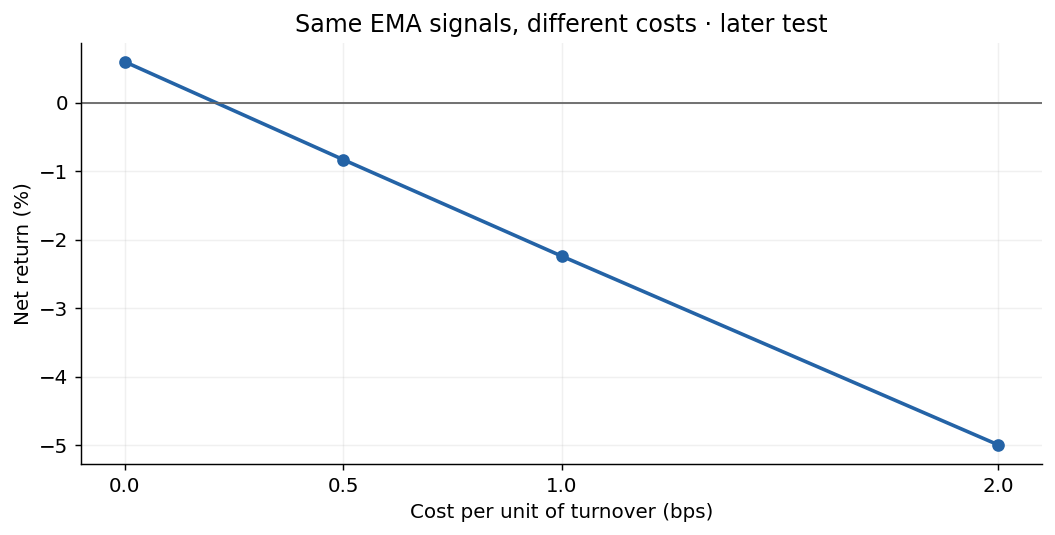

In [11]:
cost_rows = []
for cost in [0.0, 0.5, 1.0, 2.0]:
    result = backtest(features, cost_bps=cost).loc[test_mask]
    cost_rows.append({"cost per side (bps)": cost, **performance(result)})
cost_table = pd.DataFrame(cost_rows).set_index("cost per side (bps)")
display(cost_table[["gross (%)", "net (%)", "max drawdown (%)", "turnover"]].round(3))

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(cost_table.index, cost_table["net (%)"], "o-", color=BLUE, lw=2)
ax.axhline(0, color="0.4", lw=1)
ax.set(title="Same EMA signals, different costs · later test", xlabel="Cost per unit of turnover (bps)",
       ylabel="Net return (%)", xticks=cost_table.index)
plt.show()

### A 5-minute check, without making it the main test

I can aggregate the same cleaned trades to 5 minutes and rerun the rule. I keep the windows in roughly the same clock time: EMA 20 minutes, RSI/ATR rounded up to 15 minutes, and correlation 60 minutes. Using EMA(20) on both charts would compare 20 minutes with 100 minutes.

This isn’t a perfectly matched experiment. The 5-minute version has fewer correlation pairs, waits for a longer bar to finish, holds for 5 minutes, and exits at 15:55 instead of 15:59. Its Kalman process variance also scales with elapsed time. The point is to check how much the timeframe changes the behavior, not to pick a winner from five test days.

In [12]:
def five_minute_bars(minute_bars):
    pieces = []
    for _, day in minute_bars.groupby(minute_bars.index.normalize()):
        day = day.copy()
        day["price_volume"] = day["vwap"] * day["volume"]
        five = day.resample("5min").agg({"open": "first", "high": "max", "low": "min", "close": "last",
                                           "volume": "sum", "trades": "sum", "price_volume": "sum"})
        five = five.dropna(subset=["open"])
        five["vwap"] = five.pop("price_volume") / five["volume"]
        assert len(five) == 78
        pieces.append(five)
    return pd.concat(pieces)

bars5 = five_minute_bars(bars)
features5 = add_correlations(make_features(bars5, minutes=5), minutes=5)
result5 = backtest(features5)
comparison_rows = []
for minutes, result in [(1, main_result), (5, result5)]:
    for sample_name, dates in [("Earlier", train_days), ("Later test", test_days)]:
        sample = result.loc[result.index.normalize().isin(dates)]
        comparison_rows.append({"bar length (minutes)": minutes, "sample": sample_name,
                                "bars": len(sample), **performance(sample)})
timeframe_table = pd.DataFrame(comparison_rows).set_index(["bar length (minutes)", "sample"])
display(timeframe_table[["bars", "gross (%)", "net (%)", "entries incl. flips", "turnover"]].round(3))

bars  gross (%)  net (%)  entries incl. flips  turnover
bar length (minutes) sample                                                             
1                    Earlier     3900     -0.072   -2.851                  282       564
                     Later test  1950      0.594   -0.834                  143       286
5                    Earlier      780     -1.340   -2.906                  160       320
                     Later test   390      0.584   -0.218                   80       160

### A few checks before trusting the numbers

I change the later part of one session and recalculate it. Earlier features, correlations, signals, and positions should stay exactly the same. I also check the signal shift, warm-up, final exit, and RSI edge cases. The small-file checks in `tests/test_spy_data.py` cover duplicate trades, bar aggregation across chunk boundaries, and missing minutes.

In [13]:
cut = 150
original_day = bars.loc[bars.index.normalize() == example_day].copy()
changed_day = original_day.copy()
price_columns = ["open", "high", "low", "close", "vwap"]
changed_day.loc[changed_day.index[cut:], price_columns] *= 1.05
original_features = add_correlations(make_features(original_day))
changed_features = add_correlations(make_features(changed_day))
causal_columns = ["kalman", "ema", "rsi", "atr", *FEATURES, *[f"corr_{name}" for name in FEATURES]]
pd.testing.assert_frame_equal(original_features[causal_columns].iloc[:cut],
                              changed_features[causal_columns].iloc[:cut])
pd.testing.assert_frame_equal(backtest(original_features)[["signal", "position"]].iloc[:cut],
                              backtest(changed_features)[["signal", "position"]].iloc[:cut])

for _, day in main_result.groupby(main_result.index.normalize()):
    expected = day["signal"].shift(1).fillna(0)
    expected.iloc[-1] = 0
    pd.testing.assert_series_equal(day["position"], expected, check_names=False)
    unavailable = day["corr_ema_gap"].shift(1).isna()
    assert day.loc[unavailable, "position"].eq(0).all()
    assert day["position"].iloc[-1] == 0
    assert day["turnover"].iloc[-1] == abs(day["position"].iloc[-2])
    assert day["turnover"].sum() == 2 * day["entry"].sum()

# The forward diagnostic column must never decide a trade.
changed_target = features.copy()
changed_target["future_return"] = 999
pd.testing.assert_series_equal(backtest(changed_target)["signal"], main_result["signal"])

for shape, expected_rsi in [("flat", 50), ("up", 100), ("down", 0)]:
    toy = original_day.iloc[:40].copy()
    price = np.full(40, 100.0) if shape == "flat" else 100 + np.arange(40) * (1 if shape == "up" else -1)
    for column in price_columns:
        toy[column] = price
    toy["high"], toy["low"] = price + 0.1, price - 0.1
    assert np.isclose(make_features(toy)["rsi"].iloc[-1], expected_rsi)
# Check one correlation against the completed pairs by hand.
i, window = 110, CORR_MINUTES
x = original_features["ema_gap"].shift(2).iloc[i - window + 1:i + 1]
y = original_features["open"].pct_change(fill_method=None).iloc[i - window + 1:i + 1]
assert np.isclose(original_features["corr_ema_gap"].iloc[i], x.corr(y))

# A tiny example makes the price timing and flip cost visible.
toy_timing = original_features.iloc[:4].copy()
toy_timing["open"] = [100.0, 110.0, 99.0, 100.0]
toy_timing["ema_gap"] = [1.0, -1.0, 1.0, -1.0]
toy_timing["corr_ema_gap"] = 0.5
toy_result = backtest(toy_timing, cost_bps=1.0)
assert np.allclose(toy_result["position"], [0, 1, -1, 0])
assert np.allclose(toy_result["gross_return"], [0, -0.1, -(100 / 99 - 1), 0])
assert np.allclose(toy_result["cost"], [0, 0.0001, 0.0002, 0.0001])
print("Passed: future-data check, signal timing, warm-up, daily exits, turnover, and RSI edge cases.")

Passed: future-data check, signal timing, warm-up, daily exits, turnover, and RSI edge cases.


### What I’d take from this

One-minute bars are usable here. The problem is how often this rule changes its mind. EMA distance and centered RSI have almost no overall correlation with the later return in the earlier sample. A rolling window still produces trading signals, but that doesn’t make those signals reliable.

Kalman makes the indicator smoother. It doesn’t create a profitable execution price or guarantee a predictive relationship. That’s why I keep the cleaning counts, the indicator plots, and the trading results separate.

The five-minute version trades less and loses less after the same assumed cost in the later test. That’s a useful comparison, but five sessions aren’t enough to declare that timeframe better. I’d need a longer sample and quotes to measure execution costs before taking this further.

In [14]:
summary = performance(test_result)
print(f"Main EMA rule, final {len(test_days)} sessions:")
print(f"  Before costs: {summary['gross (%)']:+.3f}%")
print(f"  After costs:  {summary['net (%)']:+.3f}%")
print(f"  Max drawdown: {summary['max drawdown (%)']:.3f}%")
print(f"  Entries, including flips: {summary['entries incl. flips']}")
print(f"  Cost assumption: {COST_BPS} bp per unit of turnover")
if summary["gross (%)"] > 0 and summary["net (%)"] < 0:
    print("With these settings, the gross gain does not cover the assumed trading costs.")

Main EMA rule, final 5 sessions:
  Before costs: +0.594%
  After costs:  -0.834%
  Max drawdown: -1.625%
  Entries, including flips: 143
  Cost assumption: 0.5 bp per unit of turnover
With these settings, the gross gain does not cover the assumed trading costs.


### References for the implementation

The assignment wording and the supplied CSVs are the starting point. These links are for checking the technical details:

- [NYSE Daily TAQ specification, trade fields on pages 17–20](https://www.nyse.com/publicdocs/nyse/data/Daily_TAQ_Client_Spec_v4.3.pdf): timestamps, correction flags, and sale-condition codes.
- [pandas window calculations](https://pandas.pydata.org/docs/user_guide/window.html): recursive EMA and rolling correlation.
- [SciPy Savitzky–Golay filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html): window and edge handling for the alternative smoother.

The Kalman recursion and strategy timing are written out above, so the trading rule can be followed without those links.